# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [1]:
import pandas as pd
import sklearn

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

### Step 2.a Assign variables `X` to the features and `y` to the target

In [8]:
# الميزات (Features) والهدف (Target) تم تعيينهما بالفعل في كود التحميل
# X = auto_mpg.data.features
# y = auto_mpg.data.targets

# إذا أردت التأكد من محتواهما:
print(X.head())
print(y.head())

   displacement  cylinders  horsepower  weight  acceleration  model_year  \
0         307.0          8       130.0    3504          12.0          70   
1         350.0          8       165.0    3693          11.5          70   
2         318.0          8       150.0    3436          11.0          70   
3         304.0          8       150.0    3433          12.0          70   
4         302.0          8       140.0    3449          10.5          70   

   origin  
0       1  
1       1  
2       1  
3       1  
4       1  
    mpg
0  18.0
1  15.0
2  18.0
3  16.0
4  17.0


### Step 2.b print the type of each

In [9]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.DataFrame'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [10]:
print("The target 'mpg' is Numerical.")
print("The task is Regression.")

The target 'mpg' is Numerical.
The task is Regression.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [11]:
print(f"Number of samples in X: {X.shape[0]}")
print(f"Number of columns in X: {X.shape[1]}")
print(f"Number of samples in y: {len(y)}")

Number of samples in X: 398
Number of columns in X: 7
Number of samples in y: 398


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [12]:
# ملخص إحصائي للميزات
summary = X.describe()

# إضافة الوسيط (Median) للملخص
summary.loc['median'] = X.median()

print(summary)

        displacement   cylinders  horsepower       weight  acceleration  \
count     398.000000  398.000000  392.000000   398.000000    398.000000   
mean      193.425879    5.454774  104.469388  2970.424623     15.568090   
std       104.269838    1.701004   38.491160   846.841774      2.757689   
min        68.000000    3.000000   46.000000  1613.000000      8.000000   
25%       104.250000    4.000000   75.000000  2223.750000     13.825000   
50%       148.500000    4.000000   93.500000  2803.500000     15.500000   
75%       262.000000    8.000000  126.000000  3608.000000     17.175000   
max       455.000000    8.000000  230.000000  5140.000000     24.800000   
median    148.500000    4.000000   93.500000  2803.500000     15.500000   

        model_year      origin  
count   398.000000  398.000000  
mean     76.010050    1.572864  
std       3.697627    0.802055  
min      70.000000    1.000000  
25%      73.000000    1.000000  
50%      76.000000    1.000000  
75%      79.000000

### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

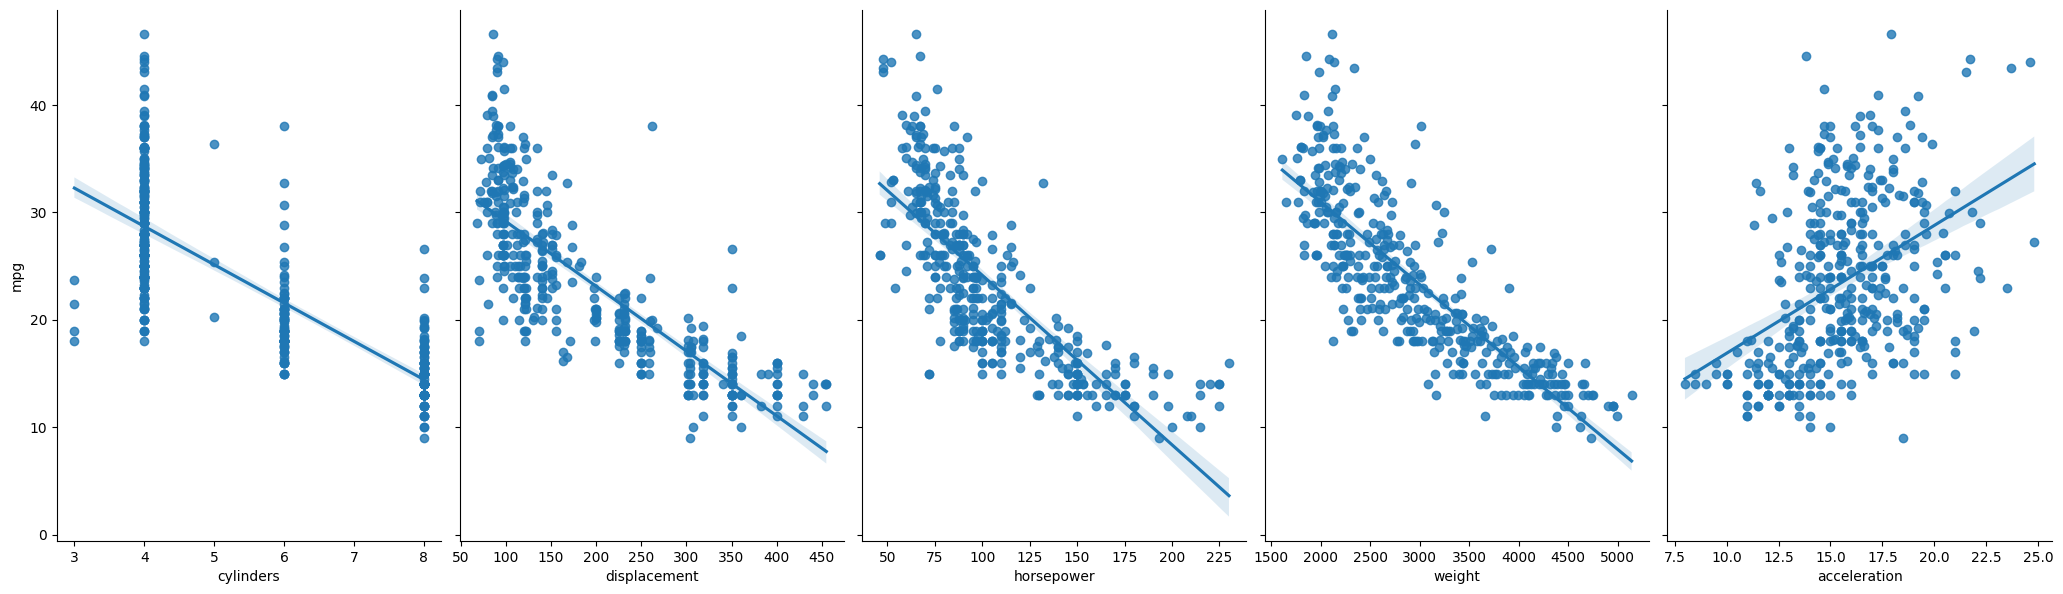

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# دمج X و y مؤقتاً للرسم
plot_df = X.copy()
plot_df['mpg'] = y

# رسم العلاقات مع خط الانحدار
sns.pairplot(plot_df, 
             x_vars=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration'], 
             y_vars='mpg', 
             height=6, aspect=0.7, kind='reg')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

In [ ]:
Cylinders and mpg: Strong Decreasing (Negative) 

Displacement and mpg: Strong Decreasing (Negative) 

Horsepower and mpg: Strong Decreasing (Negative) 

Weight and mpg: Strong Decreasing (Negative)

Acceleration and mpg: Weak Increasing (Positive) 

### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

# 1. تحديد الميزات الرقمية والفئوية
numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
categorical_features = ['model_year', 'origin'] # الميزات الفئوية

# 2. بناء معالج البيانات الرقمية (ملء الفراغات + توحيد المقاييس)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# 3. بناء معالج البيانات الفئوية (ترميز One-Hot)
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# 4. دمج المعالجات في ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. بناء الـ Pipeline النهائي مع الموديل
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("Advanced Pipeline with ColumnTransformer defined successfully!")





Advanced Pipeline with ColumnTransformer defined successfully!


### Step 8. Split the dataset into train and test sets

In [16]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات بنسبة 80% للتدريب و 20% للاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 318, Test samples: 80


### Step 9.a Fit the pipeline on the training set

In [18]:
# ملاحظة: تأكد أنك استخدمت اسم 'model_pipeline' من الخطوة السابعة
model_pipeline.fit(X_train, y_train)

print("The advanced pipeline has been trained successfully!")

The advanced pipeline has been trained successfully!


### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [19]:
# استخراج الموديل من آخر خطوة في الـ pipeline
regressor = model_pipeline.named_steps['regressor']

print(f"Model Coefficients: {regressor.coef_}")
print(f"Model Bias (Intercept): {regressor.intercept_}")

Model Coefficients: [[ 0.16873575  1.59613209 -0.93490376 -5.38274697  0.09607901 -3.65139348
  -1.83932431 -2.84668394 -4.2710877  -1.66038158 -2.56201416 -1.44248526
  -0.17979735  0.13901232  2.154391    6.44559047  3.66839103  6.04578295
  -1.83524889  1.08046533  0.75478356]]
Model Bias (Intercept): [24.45577662]


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

In [21]:
# 1. الميزات الرقمية هي أول ميزات تدخل في الـ Pipeline بالترتيب الذي وضعناه
# numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

# 2. بما أن 'weight' هو الرابع في القائمة، فإنه يأخذ الفهرس رقم 3
# لكن لضمان عدم حدوث خطأ، سنبحث عن مكانه في القائمة الرقمية فقط
weight_idx_in_numeric = numeric_features.index('weight')

# 3. استخراج المعامل الخاص بالوزن من الموديل
# (الموديل يخزن المعاملات الرقمية في البداية)
regressor = model_pipeline.named_steps['regressor']
weight_coeff = regressor.coef_[0][weight_idx_in_numeric] # أضفنا [0] لأن y قد تكون مصفوفة ثنائية

# 4. حساب الزيادة (تقليل الوزن بـ 100 وحدة)
# ملاحظة: إذا كان الوزن بالرطل (lbs) والطلب بالكيلو، نضرب في معامل تحويل، لكن هنا سنلتزم بالوحدات الموجودة
gain = weight_coeff * (-100)

print(f"Weight Coefficient: {weight_coeff:.4f}")
print(f"Estimated MPG gain for decreasing weight by 100 units: {gain:.4f}")

Weight Coefficient: -5.3827
Estimated MPG gain for decreasing weight by 100 units: 538.2747


### Step 10. Evaluate the pipeline on the test set

In [23]:
# حساب درجة الدقة R^2
score = model_pipeline.score(X_test, y_test)

print(f"The model's R^2 score on the test set is: {score:.4f}")

The model's R^2 score on the test set is: 0.8405
